# A tour of pypgl

`pypgl` binds [Pangolin](https://github.com/gfonsecabr/pgl), a plane geometry
library that computes over $\mathbb{Q}$ with arbitrary-precision integers rather
than over the floats. Every predicate is therefore *decided*, not estimated:
degeneracies are answered rather than perturbed away, and no downstream
combinatorial structure can be built on a contradictory set of orientation tests.

The surface is the usual one — shapes and their predicates, regularized boolean
and Minkowski operations, convex hulls, triangulations, arrangements, visibility,
spatial indices. This notebook covers the numerics and the core conventions;
[`booleans.ipynb`](booleans.ipynb) and [`bitmatrix.ipynb`](bitmatrix.ipynb) take
particular families further.

In [1]:
import pypgl as pgl

pgl.__version__

'1.3.0'

## Inline display

Every shape and every canvas implements `_repr_svg_`, so a shape evaluated as a
cell's last expression renders through a one-shot canvas of side
`pypgl.REPR_SVG_SIZE`.

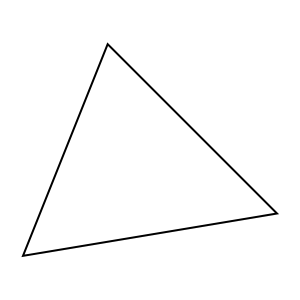

In [2]:
pgl.REPR_SVG_SIZE = 300

pgl.Triangle(0, 0, 6, 1, 2, 5)

Fixed-arity shapes take their coordinates flat, and `Convex`, `Polygon`,
`MonotoneChain` and `Polyline` accept a flat list of any even length read in
$(x, y)$ pairs.

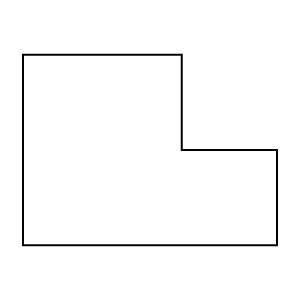

In [3]:
pgl.Polygon([0,0, 8,0, 8,3, 5,3, 5,6, 0,6])

## The number type

A coordinate is an element of $\mathbb{Q}$, held as a normalized ratio of
arbitrary-precision integers. It is written as an `int`, a `fractions.Fraction`
or an `"a/b"` string, and always read back as a `Fraction`.

`float` is refused at the boundary. Accepting one would mean choosing a rational
approximation on the user's behalf, which is the single decision the library
exists not to make.

In [4]:
from fractions import Fraction

p = pgl.Point(Fraction(3, 2), "-7/4")
print(p, "  x =", repr(p.x()))

try:
    pgl.Point(0.1, 0.2)
except TypeError as e:
    print(e)

(3/2,-7/4)   x = Fraction(3, 2)
__init__(): incompatible function arguments. The following argument types are supported:
    1. __init__(self) -> None
    2. __init__(self, x: fractions.Fraction, y: fractions.Fraction) -> None

Invoked with types: pypgl._pgl.Point, float, float


### What the floating-point predicate actually does

The familiar failure mode is not loss of accuracy in a coordinate but loss of
*consistency* in a decision. Take the standard orientation determinant

$$\mathrm{orient}(p, q, r) = (q_x - p_x)(r_y - p_y) - (q_y - p_y)(r_x - p_x)$$

evaluated in IEEE double precision, with $q = (12, 12)$, $r = (24, 24)$ fixed and
$p$ ranging over a $256 \times 256$ grid of consecutive doubles around
$(\tfrac12, \tfrac12)$ — the experiment of Kettner, Mehlhorn, Näher, Seel and
Yap, *Classroom examples of robustness problems in geometric computations*
(CGTA 40(1), 2008).

Every grid point is exactly representable, so the comparison is against ground
truth, not against a finer approximation: `Fraction(x)` converts a double
losslessly.

In [5]:
import itertools

U = 2.0 ** -53                                    # one ulp at 1/2
Q, R = (12.0, 12.0), (24.0, 24.0)

def orient(p, q, r):
    return (q[0] - p[0]) * (r[1] - p[1]) - (q[1] - p[1]) * (r[0] - p[0])

def sign(v):
    return (v > 0) - (v < 0)

line  = pgl.OrientedLine(pgl.Point(12, 12), pgl.Point(24, 24))
tally = {(f, e): 0 for f in (-1, 0, 1) for e in (-1, 0, 1)}

for i, j in itertools.product(range(256), repeat=2):
    p = (0.5 + i * U, 0.5 + j * U)
    approximate = sign(orient(p, Q, R))
    exact = line.orientation(pgl.Point(Fraction(p[0]), Fraction(p[1])))
    tally[approximate, exact] += 1

print("            exact -1   exact 0   exact +1")
for f in (-1, 0, 1):
    print(f"double {f:+d}  " + "".join(f"{tally[f, e]:10d}" for e in (-1, 0, 1)))

wrong = sum(n for (f, e), n in tally.items() if f != e)
false_zero = tally[0, -1] + tally[0, 1]
print(f"\nwrong in {wrong} of 65536 triples ({100 * wrong / 65536:.1f}%): "
      f"{false_zero} spurious collinearities, {wrong - false_zero} reversed signs")

            exact -1   exact 0   exact +1
double -1       26654         0       336
double +0        5650       256      5650
double +1         336         0     26654

wrong in 11972 of 65536 triples (18.3%): 11300 spurious collinearities, 672 reversed signs


The off-diagonal mass is the point. A sixth of the grid is reported collinear
when it is not, and several hundred triples come back with the sign *reversed* —
the double-precision predicate is not merely imprecise but non-monotone, and a
sweep or an incremental construction consuming it can produce a structure no
input realizes, or fail to terminate. `line.orientation(p)` returns the sign of
the same determinant evaluated in $\mathbb{Q}$, so its 65536 answers are correct
by construction.

The cost is coefficient growth rather than range: `BigInt` does not overflow, but
arithmetic is no longer constant time and the bit length of an intermediate grows
with the depth of the construction.

In [6]:
big = 10**30
long_segment = pgl.Segment(0, 0, big, big + 1)

print(long_segment.midpoint())
print("incident:", long_segment.contains(long_segment.midpoint()))

(500000000000000000000000000000,1000000000000000000000000000001/2)
incident: True


## Predicates

Seven predicates are total over the seventeen shape classes — every ordered pair,
$17 \times 17$, with no gaps to work around. Writing $\partial A$ for the
manifold boundary (the two endpoints, for a one-dimensional shape):

| | |
| --- | --- |
| `A.contains(B)` | $A \supseteq B$ |
| `A.boundaryContains(B)` | $\partial A \supseteq B$ |
| `A.interiorContains(B)` | $A^{\circ} \supseteq B$ |
| `A.intersects(B)` | $A \cap B \neq \emptyset$ |
| `A.interiorsIntersect(B)` | $A^{\circ} \cap B^{\circ} \neq \emptyset$ |
| `A.separates(B)` | $B \setminus A$ disconnected |
| `A.crosses(B)` | $A \setminus B$ and $B \setminus A$ both disconnected |

In [7]:
tri  = pgl.Triangle(0, 0, 6, 0, 3, 5)
wire = pgl.Segment(-2, 2, 8, 2)        # enters through one side, leaves by another

for name in ("contains", "intersects", "interiorsIntersect", "separates", "crosses"):
    print(f"{name:20} {getattr(tri, name)(wire)}")

contains             False
intersects           True
interiorsIntersect   True
separates            True
crosses              True


`point in shape` is bound to `shape.contains(point)`. It is deliberately limited
to point membership: shape-against-shape stays an explicit call, so `in` never
has to mean one of seven things.

In [8]:
print(pgl.Point(3, 2) in tri, pgl.Point(9, 9) in tri)

True False


## `intersection` is a sum type

The intersection of two shapes has no fixed dimension, so the return type varies
with the answer: `None`, a `Point`, or a `Segment`, mapped from the C++ variant
rather than flattened onto a sentinel.

In [9]:
pairs = [
    (pgl.Segment(0, 0, 4, 4), pgl.Segment(0, 4, 4, 0)),   # transversal
    (pgl.Segment(0, 0, 4, 0), pgl.Segment(2, 0, 6, 0)),   # collinear overlap
    (pgl.Segment(0, 0, 1, 1), pgl.Segment(5, 5, 6, 6)),   # disjoint
]
for s, t in pairs:
    r = s.intersection(t)
    print(f"{type(r).__name__:8} {r}")

Point    (2,2)
Segment  (2,0)--(4,0)
NoneType None


## Measures

$\mathbb{Q}$ is closed under the field operations but not under radicals, which
partitions the measures exactly. An area or a squared distance is rational and
returns a `Fraction`; a length or a distance is not, and returns a `float`.

Every quantity of the second kind has a squared counterpart, so a comparison
against a threshold need never leave $\mathbb{Q}$: test $d^2 \le t^2$, not
$d \le t$.

In [10]:
tri  = pgl.Triangle(0, 0, 5, 0, 0, 4)
side = pgl.Segment(0, 0, 5, 4)
far  = pgl.Point(9, 8)

print("area:            ", repr(tri.area()))
print("squared distance:", repr(tri.squaredDistance(far)))
print("squared length:  ", repr(side.squaredLength()))
print("length:          ", side.length())

print("within 9, decided in Q:", tri.squaredDistance(far) <= 9 ** 2)

area:             Fraction(10, 1)
squared distance: Fraction(3136, 41)
squared length:   Fraction(41, 1)
length:           6.4031242374328485
within 9, decided in Q: True


## Canvas

`Canvas` is a renderer for inspection and figures, not a plotting layer: it fits
the drawn geometry, clips unbounded primitives to the viewport, and exports SVG,
PDF or Ipe. Style commands apply to what is drawn after them, and every call
returns the canvas.

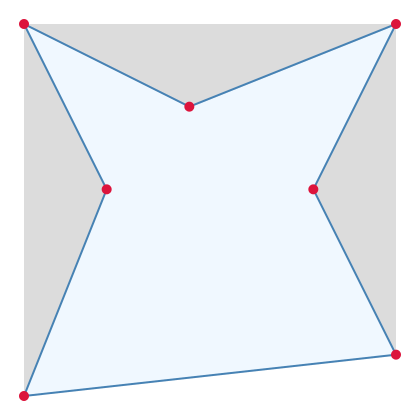

In [11]:
poly = pgl.Polygon([0,0, 9,1, 7,5, 9,9, 4,7, 0,9, 2,5])
hull = poly.convexHull()

canvas = pgl.Canvas().size(420, 420).margin(20)
canvas.stroke("none").fill("gainsboro").draw(hull)
canvas.stroke("steelblue").fill("aliceblue").strokeWidth(2).draw(poly)
canvas.stroke("crimson").fill("crimson").pointRadius(4).draw(poly.vertices())
canvas

`draw` accepts any iterable as well as a single shape, which is how the vertices
went in as one call. `toSVG()`, `toPDF()` and `toIPE()` return the document;
`writeSVG`, `writePDF` and `writeIPE` put it on disk.

In [12]:
len(canvas.toSVG()), canvas.toPDF()[:5]

(1935, b'%PDF-')

## Further

- [`booleans.ipynb`](booleans.ipynb) — regularized boolean operations, Minkowski
  sums and erosions, and the result types each pair admits.
- [`bitmatrix.ipynb`](bitmatrix.ipynb) — the digital-geometry grid: rasterization,
  set algebra, morphology and connectivity a machine word at a time.
- [`motion.ipynb`](motion.ipynb) — translational motion planning end to end:
  configuration space, reduced visibility graph, A*.
- [`examples/`](..) — the same material as scripts, one per upstream C++ example.
- [`doc/`](../../doc) — shapes, methods, algorithms, data structures, canvas.